In [19]:
import open3d as o3d
import numpy as np
from scipy.spatial import KDTree

Create own synthetic data

In [ ]:
np.random.seed(42)
S = np.random.rand(1000, 3)
S

array([[0.37454012, 0.95071431, 0.73199394],
       [0.59865848, 0.15601864, 0.15599452],
       [0.05808361, 0.86617615, 0.60111501],
       ...,
       [0.80000348, 0.55270708, 0.39655368],
       [0.13171503, 0.86529576, 0.15727321],
       [0.30978786, 0.29004553, 0.87141403]], shape=(1000, 3))

In [3]:
T = S + np.random.normal(0, 0.01, S.shape)

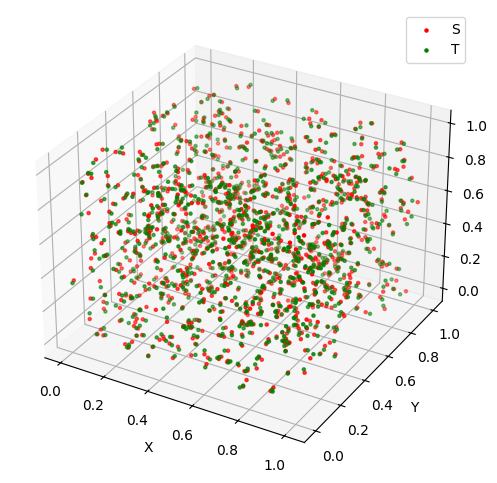

In [4]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(S[:, 0], S[:, 1], S[:, 2], c='r', label='S', s=5)
ax.scatter(T[:, 0], T[:, 1], T[:, 2], c='g', label='T', s=5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [5]:
tree_T = KDTree(T)
def print_all_properties(obj):
    print(f"All properties of {type(obj).__name__}:")
    for attr in dir(obj):
        # Filter out private/protected and methods
        # if not attr.startswith('_'):
        value = getattr(obj, attr)
        if not callable(value):
            print(f"{attr}: {value}")

print_all_properties(tree_T)

All properties of KDTree:
__dict__: {}
__doc__: kd-tree for quick nearest-neighbor lookup.

    This class provides an index into a set of k-dimensional points
    which can be used to rapidly look up the nearest neighbors of any
    point.

    Parameters
    ----------
    data : array_like, shape (n,m)
        The n data points of dimension m to be indexed. This array is
        not copied unless this is necessary to produce a contiguous
        array of doubles, and so modifying this data will result in
        bogus results. The data are also copied if the kd-tree is built
        with copy_data=True.
    leafsize : positive int, optional
        The number of points at which the algorithm switches over to
        brute-force.  Default: 10.
    compact_nodes : bool, optional
        If True, the kd-tree is built to shrink the hyperrectangles to
        the actual data range. This usually gives a more compact tree that
        is robust against degenerated input data and gives fast

In [6]:
distances_T_to_S, indices_T = tree_T.query(S, k=1)

In [9]:
rmse1 = np.mean(np.linalg.norm(T - S[indices_T, :], axis=1))
rmse2 = np.sqrt(np.mean(distances_T_to_S) ** 2)
print(f"{rmse1=}")
print(f"{rmse2=}")

rmse1=np.float64(0.016226661923829894)
rmse2=np.float64(0.015879217955186452)


In [23]:
# For chamfer distance
# it's symmetric NN distance calculation
# So, for every NN in T to S, and for every NN in S from T

tree_S = KDTree(S)
distances_S_to_T, indices_S = tree_S.query(T, k=1)

chamfer_distance = np.mean(distances_S_to_T) + np.mean(distances_T_to_S)
print(f"Chamfer Distance: {chamfer_distance}")

Chamfer Distance: 0.03171301560919197


In [31]:
# For Hausdorff distance
hausdorff = max(np.max(distances_T_to_S), np.max(distances_S_to_T))
print("Hausdorff Distance:", hausdorff)

Hausdorff Distance: 0.03983609176084227


In [22]:
# mutual nearest neighbors
print(f"Closest points in S to each point in T: {indices_S}")
print(f"Closest points in T to each point in S: {indices_T}")

# IMPLEMENT!

Closest points in S to each point in T: [  0   1   2   3   4   5   6   7   8   9  10  11 574  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28 476  30 938  32  33  34  35
  36  37  38  39  40  41  42  43 612  45  46  47  48  49  50  51  52  53
  54  84  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95 325  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 202 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 615 223 224 225 226 227 228 229 230 231 232 233
 234 235 23